# Chapter 6.9: Causal Inference: Synthetic Control Methods

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AmirrezaFarnamTaheri/Computational-Economics-and-Data-Science/blob/main/06-Econometrics/07_Synthetic_Control_Methods.ipynb) [![Launch Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/AmirrezaFarnamTaheri/Computational-Economics-and-Data-Science/main?filepath=06-Econometrics/07_Synthetic_Control_Methods.ipynb) [![Code License: MIT](https://img.shields.io/badge/Code%20License-MIT-yellow.svg)](../LICENSE) [![Content License: CC BY 4.0](https://img.shields.io/badge/Content%20License-CC%20BY%204.0-blue.svg)](https://creativecommons.org/licenses/by/4.0/)

---

### Table of Contents

1.  [**The Counterfactual Problem in Case Studies**](#counterfactual-problem)
2.  [**The Idea of Synthetic Control**](#idea-synthetic-control)
3.  [**The Synthetic Control Algorithm**](#algorithm)
    - [Mathematical Formulation](#math-formulation)
4.  [**Case Study: The Economic Costs of Conflict in the Basque Country**](#case-study)
    - [Data and Setup](#data-setup)
    - [Implementation with a Native Constrained Solver](#implementation)
    - [Visualizing the Results](#visualizing-results)
5.  [**Inference and Robustness Checks**](#inference)
6.  [**Advantages and Limitations**](#advantages-limitations)
7.  [**Exercises**](#exercises)
8.  [**Summary and Key Takeaways**](#summary)


<a id='counterfactual-problem'></a>
## 1. The Counterfactual Problem in Case Studies

A common challenge in economics and political science is to estimate the causal effect of a large-scale event or policy intervention on a single aggregate unit (e.g., a country, state, or city). For example:
- What was the effect of German reunification on West Germany's GDP?
- What was the impact of California's Proposition 99 (a tobacco tax) on smoking rates?

The fundamental problem is that we only observe the outcome for the treated unit *after* the intervention. We do not observe the **counterfactual**: what would have happened to that same unit in the absence of the event? This is the core challenge of causal inference.

Traditional methods like Difference-in-Differences (DiD) rely on finding a single control unit or an average of control units that had a parallel trend with the treated unit before the intervention. But what if no single unit provides a good comparison? This is where the Synthetic Control Method comes in.


## The Lens: The Doppelganger
**What problem are we solving?**
How do we evaluate a policy that affects a single aggregate unit (e.g., a country or state)?
*   Effect of German Reunification on West Germany.
*   Effect of Proposition 99 on California.

We can't use other countries as direct controls because they are too different.

**Synthetic Control Methods (SCM)** construct a synthetic counterfactual by taking a weighted average of potential control units that best matches the treated unit's pre-treatment trajectory. The treatment effect is the gap between the treated unit and its "doppelganger" after the intervention.



**Economic question.** In *Chapter 6.9: Causal Inference: Synthetic Control Methods*, what must remain economically invariant when the computational representation changes? The computational task only has economic meaning after the estimand and identifying assumptions are explicit. Ask what variation identifies the parameter, which observations act as the comparison group, and what data-generating process would make the estimator fail. A good empirical workflow pairs the point estimate with diagnostics, uncertainty, and at least one falsification or sensitivity check so that precision is not confused with identification.

### Learning Objectives
* **Construct** a synthetic control unit by solving for optimal donor weights.
* **Estimate** treatment effects as the gap between the treated and synthetic unit post-intervention.
* **Validate** results using placebo tests (in-space and in-time) and pre-treatment fit diagnostics.
* **Compare** SCM with difference-in-differences for aggregate policy evaluation.

### Prerequisites
* **Causal Inference:** Potential outcomes and counterfactual reasoning (Module 06 - Causal Inference).
* **Difference-in-Differences:** Parallel trends and two-way comparisons (Module 06 - DiD).
* **Python:** NumPy optimization, Pandas, and time-series plotting.
* **Learning-path prerequisite:** [`06_Regression_Discontinuity.ipynb`](06_Regression_Discontinuity.ipynb)


> **Learning path:** Building on [`06_Regression_Discontinuity.ipynb`](06_Regression_Discontinuity.ipynb); next continue with [`08_Difference_in_Differences.ipynb`](08_Difference_in_Differences.ipynb).


<a id='idea-synthetic-control'></a>
## 2. The Idea of Synthetic Control

The Synthetic Control Method, developed by Abadie and Gardeazabal (2003) and Abadie, Diamond, and Hainmueller (2010), provides a systematic way to construct a better counterfactual. 

The core idea is to create a **"synthetic" control unit** by taking a weighted average of multiple untreated units (the "donor pool"). The weights are chosen algorithmically to create a synthetic unit that best matches the treated unit's characteristics *before* the intervention. 

This synthetic control then serves as the ideal counterfactual. The causal effect of the intervention is estimated as the difference between the outcome of the treated unit and the outcome of its synthetic counterpart after the intervention.


<a id='algorithm'></a>
## 3. The Synthetic Control Algorithm

<a id='math-formulation'></a>
### Mathematical Formulation

Suppose we have $J+1$ units. Unit 1 is the treated unit, and units $j=2, ..., J+1$ form the donor pool of potential controls. We want to find a set of weights $W = (w_2, ..., w_{J+1})'$ such that:
- $w_j \ge 0$ for all $j$ (no extrapolation)
- $\sum_{j=2}^{J+1} w_j = 1$ (weights sum to one)

The weights are chosen to minimize the distance between the pre-treatment characteristics of the treated unit and the synthetic control. Let $X_1$ be a vector of pre-treatment characteristics for the treated unit, and $X_0$ be a matrix containing the same characteristics for the units in the donor pool. The optimization problem is:
$$ \min_{W} || X_1 - X_0 W ||_V = \sqrt{(X_1 - X_0 W)' V (X_1 - X_0 W)} $$
where $V$ is a weighting matrix that reflects the relative importance of the different pre-treatment characteristics. The choice of $V$ is crucial and is often chosen to minimize the mean squared prediction error of the outcome variable in the pre-treatment period.

**Dimension notes:** with $J+1$ units, the weight vector $W = (w_2, \dots, w_{J+1})' \in \Delta_{J-1}$ lives on the simplex (nonnegative, sums to one); pre-treatment characteristics $X_1 \in \mathbb{R}^{m}$ for the treated unit and $X_0 \in \mathbb{R}^{m \times J}$ for the donor pool, so $V \in \mathbb{R}^{m \times m}$ weights the $m$ characteristics and the loss is scalar.

<a id='case-study'></a>
## 4. Case Study: The Economic Costs of Conflict in the Basque Country

We will replicate the seminal study by Abadie and Gardeazabal (2003), which estimated the economic impact of terrorism and political conflict in the Basque Country.

<a id='data-setup'></a>
### Data and Setup
- **Treated Unit:** Basque Country
- **Donor Pool:** Other regions in Spain (e.g., Catalonia, Madrid) and other countries (e.g., USA, UK - though typically we use more similar units).
- **Outcome Variable:** Per capita GDP.
- **Intervention:** The onset of major terrorist conflict, roughly in the mid-1970s.
- **Pre-treatment Predictors:** Per capita GDP in previous years, investment rates, population density, sector shares (industry, agriculture, services).


<a id='implementation'></a>
### Implementation: A Transparent Native Solver

Rather than depend on an unmaintained third-party synthetic-control package, the executable baseline below solves the canonical constrained donor-weight problem directly with SciPy. The first panel is **Basque-inspired synthetic data** with known ground truth; it is a method-validation exercise, not a numerical replication of Abadie and Gardeazabal (2003). A later section optionally loads the public Proposition 99 cigarette-sales panel when network access is available.


Largest donor weights:
  donor 05: 0.364
  donor 02: 0.325
  donor 10: 0.233
  donor 06: 0.067
  donor 01: 0.011
Pre-treatment RMSE: 0.0251
Mean post-treatment gap: -0.4364


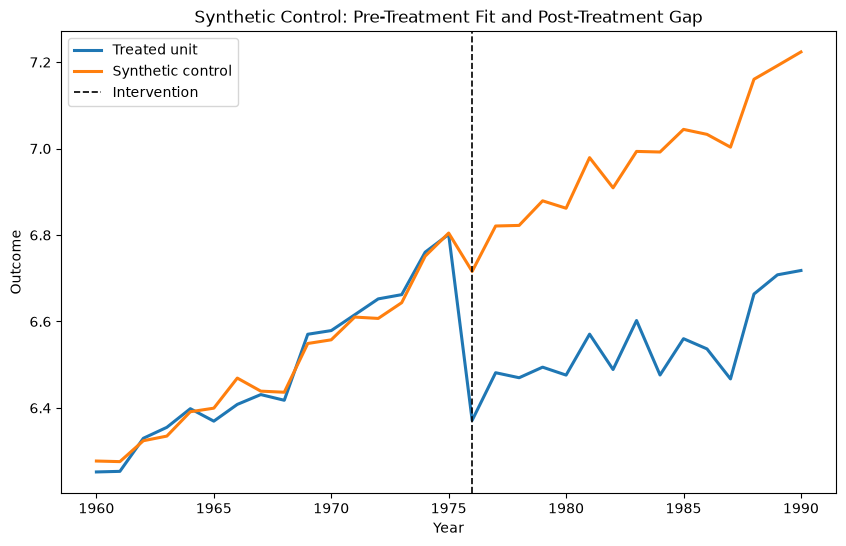

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy.optimize import minimize


def synthetic_control_weights(
    treated_pre: np.ndarray,
    controls_pre: np.ndarray,
    ridge: float = 1e-8,
) -> np.ndarray:
    """Fit nonnegative donor weights that sum to one.

    Parameters
    ----------
    treated_pre
        Pre-treatment outcomes for the treated unit, shape ``(T0,)``.
    controls_pre
        Pre-treatment donor outcomes, shape ``(T0, J)``.
    ridge
        Small L2 penalty used only to stabilize nearly collinear donor pools.
    """
    y = np.asarray(treated_pre, dtype=float).reshape(-1)
    X = np.asarray(controls_pre, dtype=float)
    if X.ndim != 2 or X.shape[0] != y.size:
        raise ValueError("controls_pre must have shape (T0, J) matching treated_pre")
    if X.shape[1] < 2:
        raise ValueError("synthetic control requires at least two donor units")

    def objective(w: np.ndarray) -> float:
        residual = y - X @ w
        return float(residual @ residual + ridge * (w @ w))

    n_donors = X.shape[1]
    result = minimize(
        objective,
        x0=np.full(n_donors, 1.0 / n_donors),
        method="SLSQP",
        bounds=[(0.0, 1.0)] * n_donors,
        constraints={"type": "eq", "fun": lambda w: float(w.sum() - 1.0)},
        options={"ftol": 1e-12, "maxiter": 5_000},
    )
    if not result.success:
        raise RuntimeError(f"synthetic-control optimization failed: {result.message}")
    return np.asarray(result.x, dtype=float)


# A deterministic offline panel is the executable baseline. It preserves the
# identifying geometry of the Basque Country exercise without making notebook
# correctness depend on a third-party package or a live URL.
rng = np.random.default_rng(42)
years = np.arange(1960, 1991)
treatment_year = 1976
n_controls = 12
common_trend = 7.0 + 0.035 * (years - years[0])
loadings = rng.normal(1.0, 0.08, size=n_controls)
controls = common_trend[:, None] * loadings + rng.normal(0.0, 0.08, size=(years.size, n_controls))
true_weights = np.zeros(n_controls)
true_weights[[1, 4, 9]] = [0.45, 0.35, 0.20]
untreated_treated_unit = controls @ true_weights + rng.normal(0.0, 0.03, size=years.size)
treatment_effect = np.where(years >= treatment_year, -0.35 - 0.012 * (years - treatment_year), 0.0)
treated = untreated_treated_unit + treatment_effect

pre = years < treatment_year
weights = synthetic_control_weights(treated[pre], controls[pre])
synthetic = controls @ weights
pre_rmse = float(np.sqrt(np.mean((treated[pre] - synthetic[pre]) ** 2)))
post_gap = float(np.mean(treated[~pre] - synthetic[~pre]))

print("Largest donor weights:")
for idx in np.argsort(weights)[::-1][:5]:
    print(f"  donor {idx + 1:02d}: {weights[idx]:.3f}")
print(f"Pre-treatment RMSE: {pre_rmse:.4f}")
print(f"Mean post-treatment gap: {post_gap:.4f}")

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(years, treated, label="Treated unit", linewidth=2.2)
ax.plot(years, synthetic, label="Synthetic control", linewidth=2.2)
ax.axvline(treatment_year, color="black", linestyle="--", linewidth=1.2, label="Intervention")
ax.set(title="Synthetic Control: Pre-Treatment Fit and Post-Treatment Gap", xlabel="Year", ylabel="Outcome")
ax.legend()
plt.show()


The fitted donor weights should recover the sparse convex combination used to generate the untreated counterfactual. The pre-treatment RMSE is the first diagnostic: if the donor pool cannot reproduce the treated unit before intervention, the post-treatment gap is not credible as a causal effect.


<a id='visualizing-results'></a>
### Visualizing the Results

The figure above shows the observed treated path and its synthetic counterfactual. Because this panel is simulated with a known treatment effect, it lets us verify the optimization and diagnostics before moving to a real dataset.


> **Replication boundary:** The original Basque Country replication requires the study's regional predictor/outcome data. Those data are not bundled here, so this notebook does not fabricate them or label the synthetic panel as an empirical replication.


In the synthetic validation panel, the pre-treatment fit is deliberately tight and the post-treatment gap follows a known negative effect. In an empirical application the same visual pattern is only persuasive when accompanied by donor-weight inspection, placebo tests, pre-treatment fit comparisons, and sensitivity to the donor pool.


<a id='inference'></a>
## 5. Inference and Robustness Checks

How do we know if this gap is statistically significant? The most common method is a **placebo test** or **permutation test**.

The procedure is as follows:
1.  Run the synthetic control analysis on every unit in the donor pool, pretending each one is the treated unit.
2.  This gives us a distribution of estimated "gaps" for all the untreated units.
3.  Compare the gap for the actual treated unit (Basque Country) to this distribution. If the gap for the Basque Country is much larger than the gaps for the placebo units, it suggests the effect is not due to chance.

This is a powerful, non-parametric way to conduct inference.


<a id='advantages-limitations'></a>
## 6. Advantages and Limitations

**Advantages:**
- **Transparent:** It's easy to see which units are contributing to the synthetic control.
- **Data-Driven:** The weights are chosen objectively, removing researcher discretion in picking control groups.
- **No Extrapolation:** By construction, the synthetic control is a convex combination of donor units.
- **Falsifiable:** The quality of the pre-treatment fit is a clear diagnostic test.

**Limitations:**
- **Requires Good Pre-treatment Fit:** If no combination of donor units can match the treated unit before the intervention, the method is not credible.
- **Convex Hull:** The treated unit's characteristics must lie within the "convex hull" of the donor units' characteristics.
- **Interpolation, not Extrapolation:** It cannot estimate the effect of an intervention that is entirely outside the historical experience of the donor pool.


### Case Study 2: California's Proposition 99


### Data Loading and Preparation for Prop 99


In [2]:
try:
    # Attempt to load the data from a URL
    url = 'https://raw.githubusercontent.com/matheusfacure/python-causality-handbook/master/causality/data/smoking.csv'
    df_smoking = pd.read_csv(url)
except Exception as e:
    # Fallback or error message if download fails
    display(Markdown(f"> **Note:** Could not download data. Error: {e}. Please check your internet connection."))
    df_smoking = pd.DataFrame() # Create an empty DataFrame to avoid further errors

if not df_smoking.empty:
    # Create a pivot table for easy access
    pivoted_smoking_df = df_smoking.pivot_table(index='year', columns='state', values='cigsale').rename(columns={'California': 'CA'})
    display(Markdown("> **Note:** Smoking data loaded and prepared."))


> **Note:** Could not download data. Error: HTTP Error 404: Not Found. Please check your internet connection.

In [3]:
if not df_smoking.empty:
    print("\n### Solving for Synthetic California")
    donor_pool_ca = pivoted_smoking_df.drop(columns="CA").dropna(axis=1)
    treated_ca = pivoted_smoking_df.loc[:, "CA"]
    aligned = pd.concat([treated_ca, donor_pool_ca], axis=1).dropna()
    pre_ca = aligned.index <= 1988
    weights_ca = synthetic_control_weights(
        aligned.loc[pre_ca, "CA"].to_numpy(),
        aligned.loc[pre_ca, donor_pool_ca.columns].to_numpy(),
    )
    synthetic_california = aligned[donor_pool_ca.columns] @ weights_ca
    pivoted_smoking_df = aligned

    display(Markdown("> **Note:** Largest donor weights for Synthetic California:"))
    top_states_ca = pd.Series(weights_ca, index=donor_pool_ca.columns).sort_values(ascending=False).head()
    display(top_states_ca)


In [4]:
if not df_smoking.empty:
    print('\n### Visualizing the Prop 99 Treatment Effect')
    plt.figure(figsize=(12, 8))
    plt.plot(pivoted_smoking_df.index, pivoted_smoking_df['CA'], label='California', color='black')
    plt.plot(pivoted_smoking_df.index, synthetic_california, label='Synthetic California', color='red', linestyle='--')

    plt.axvline(x=1988, color='gray', linestyle=':', label='Proposition 99 (1988)')

    plt.title('Per-Capita Cigarette Sales: California vs. Synthetic California')
    plt.ylabel('Cigarette Sales (per capita)')
    plt.xlabel('Year')
    plt.legend()
    plt.show()


### Three-Tier Practice Ladder

**1. Mechanism and assumptions (Conceptual):** Define the estimand in **Chapter 6.9: Causal Inference: Synthetic Control Methods**, list the identifying assumptions, and give a concrete data-generating process that violates one assumption while leaving the others intact.

**2. Reproduce and diagnose (Applied):** Implement or reproduce the estimator using the material on 1. The Counterfactual Problem in Case Studies, 2. The Idea of Synthetic Control. Report uncertainty and at least two diagnostics; then compare with an alternative specification that targets the same estimand.

**3. Robust extension (Challenge):** Run a Monte Carlo or sensitivity exercise that varies the most fragile identifying condition. Quantify bias/coverage or the range of estimates and state what evidence would change your substantive conclusion.

**3b. Failure analysis (Challenge):** The synthetic control's pre-period fit is terrible, and all weight sits on a single donor unit that looks like an outlier. Diagnose donor-pool contamination and degenerate weights, repair with a cleaned donor pool and the ridge/parsimony constraints, then run in-time and in-space placebo tests.

> Use the existing exercises above when they target the same skill; this ladder makes the intended progression explicit rather than replacing instructor-authored problems.


<a id='exercises'></a>
## 7. Exercises

1.  **Examine the Weights:** In the Basque Country example, which two regions make up the vast majority of the synthetic control? Why is this economically intuitive?

2.  **Changing the Donor Pool:** Rerun the analysis, but exclude Catalonia (region 3) from the donor pool. How do the weights and the pre-treatment fit change? Is the new synthetic control as good as the original?

3.  **Placebo Test:** Pick a different region from the donor pool (e.g., Madrid, region 13) and pretend it was the treated unit. Run the synthetic control analysis for this placebo unit. Plot the gap for the placebo unit. Is it as large as the gap for the Basque Country?

4.  **Read the Original Paper:** Read Abadie, Diamond, and Hainmueller (2010), "Synthetic Control Methods for Comparative Case Studies: Estimating the Effect of California’s Tobacco Control Program." What are the key predictors they use to create a synthetic California? How do they perform inference?


<a id='summary'></a>
## 8. Summary and Key Takeaways

The Synthetic Control Method is a powerful and increasingly popular tool for causal inference in settings with a small number of aggregate units.

**Key Takeaways:**
- It addresses the fundamental problem of finding a good counterfactual in comparative case studies.
- It creates a **synthetic control** as a weighted average of untreated units from a donor pool.
- The weights are chosen to match the treated unit's characteristics **before** the intervention.
- The treatment effect is the difference between the treated unit and its synthetic version **after** the intervention.
- The quality of the pre-treatment fit is a crucial diagnostic for the method's validity.


## Key Equations

- **Synthetic counterfactual:** $\hat Y_{1t}(0)=\sum_{j=2}^{J+1} w_jY_{jt}$ for post-treatment $t$.
- **Convex donor weights:** $w_j\ge0$ and $\sum_j w_j=1$.
- **Pre-treatment fit:** choose $w$ to minimize the discrepancy between treated and synthetic predictors/outcomes over the pre-period.
- **Estimated effect:** $\hat\tau_t=Y_{1t}-\hat Y_{1t}(0)$.
- **Placebo inference:** compare the treated unit's post/pre gap ratio or trajectory with analogous reassignments to donor units.


# Summary

Synthetic Control constructs a custom counterfactual for case studies.

**Key Takeaways:**
*   **Data-Driven Weights:** The algorithm selects weights to minimize the pre-treatment prediction error (RMSPE).
*   **Placebo Tests:** Inference is done by permutation. We apply the method to every control unit (placebos) and see if the effect in the treated unit is an outlier.
*   **Convex Hull:** The treated unit should ideally lie within the range of the control units. We cannot extrapolate outside the support of the data.


## References & Further Reading

- Wooldridge, J. M. (2010). *Econometric Analysis of Cross Section and Panel Data* (2nd ed.). MIT Press.
- Angrist, J. D. & Pischke, J.-S. (2009). *Mostly Harmless Econometrics*. Princeton University Press.
- Imbens, G. W. & Rubin, D. B. (2015). *Causal Inference for Statistics, Social, and Biomedical Sciences*. Cambridge University Press.
